# U.S. Labor Market Demography Analysis (BLS)

End-to-end pipeline using **monthly, seasonally adjusted** BLS Current Population Survey series from `../data/`.

**Business questions**
1. How has the employment gap between men and women changed over time?
2. Are employment differences driven more by labor force participation or unemployment?
3. Do men and women experience unemployment differently over time?
4. How does prime-age (25–54) employment compare to overall gender employment trends?
5. Is the gender employment gap shrinking because women improve, men decline, or both?

**Data note:** All `LNS…` series used here are the standard **seasonally adjusted** monthly releases. `Men_BLS.csv` contains extra quarterly rows (`LNS12000002Q`); the pipeline keeps only **monthly** `LNS12000001` for men’s employment.


In [1]:
# --- Setup ---
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Chart style (fallback if seaborn v0.8 style name unavailable)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass

plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 50)
print("Data:", DATA_DIR.resolve())
print("Outputs:", OUTPUT_DIR.resolve())


Data: C:\Github\demography-hiring-analysis\data
Outputs: C:\Github\demography-hiring-analysis\outputs


## 1) Data loading and cleaning

**What:** Read each CSV, validate the BLS `Series ID`, keep **only monthly** rows (`Period` = M01…M12), coerce `Value` to numeric (`-` → NaN), parse `Label` to `Date`, sort.

**Why:** Mixed frequency or wrong series IDs break merges and conclusions. This enforces a single monthly timeline aligned to `Date`.

**Series IDs (seasonally adjusted, monthly):**
| File | Series ID | Metric |
|------|-------------|--------|
| Men_BLS.csv | LNS12000001 | Men employment (thousands) |
| Women_BLS.csv | LNS12000002 | Women employment (thousands) |
| Employment Level_25-54 yrs.csv | LNS12000060 | Prime-age employment (thousands) |
| Unemployment Rate - Men.csv | LNS14000001 | Men unemployment (%) |
| Unemployment Rate - Women.csv | LNS14000002 | Women unemployment (%) |
| Labor Force Participation Rate - Men.csv | LNS11300001 | Men participation (%) |
| Labor Force Participation Rate - Women.csv | LNS11300002 | Women participation (%) |


In [2]:
def load_clean_series(
    file_name: str,
    value_name: str,
    expected_series_id: str,
) -> pd.DataFrame:
    path = DATA_DIR / file_name
    df = pd.read_csv(path)

    ids = df["Series ID"].astype(str).unique().tolist()
    if expected_series_id not in ids:
        raise ValueError(f"{file_name}: expected Series ID {expected_series_id}, got {ids}")

    df = df[df["Series ID"].astype(str) == expected_series_id].copy()
    df = df[df["Period"].astype(str).str.match(r"^M[0-9]{2}$", na=False)].copy()

    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df["Date"] = pd.to_datetime(df["Label"], format="%Y %b", errors="coerce")

    out = df[["Date", "Value"]].rename(columns={"Value": value_name})
    out = out.sort_values("Date").reset_index(drop=True)

    n_miss = int(out[value_name].isna().sum())
    print(f"{file_name}: n={len(out)}  missing {value_name}: {n_miss}")
    return out


men_emp = load_clean_series("Men_BLS.csv", "Men_Employment", "LNS12000001")
women_emp = load_clean_series("Women_BLS.csv", "Women_Employment", "LNS12000002")
prime_emp = load_clean_series("Employment Level_25-54 yrs.csv", "Prime_Age_Employment", "LNS12000060")
men_u = load_clean_series("Unemployment Rate - Men.csv", "Men_Unemployment", "LNS14000001")
women_u = load_clean_series("Unemployment Rate - Women.csv", "Women_Unemployment", "LNS14000002")
men_p = load_clean_series("Labor Force Participation Rate - Men.csv", "Men_Participation", "LNS11300001")
women_p = load_clean_series(
    "Labor Force Participation Rate - Women.csv", "Women_Participation", "LNS11300002"
)


Men_BLS.csv: n=27  missing Men_Employment: 1
Women_BLS.csv: n=27  missing Women_Employment: 1
Employment Level_25-54 yrs.csv: n=27  missing Prime_Age_Employment: 1
Unemployment Rate - Men.csv: n=27  missing Men_Unemployment: 1
Unemployment Rate - Women.csv: n=27  missing Women_Unemployment: 1
Labor Force Participation Rate - Men.csv: n=27  missing Men_Participation: 1
Labor Force Participation Rate - Women.csv: n=27  missing Women_Participation: 1


## 2) Alignment and merging

**What:** Outer merge all series on `Date`, sort, keep the canonical column set.

**Why:** One row per month with all metrics supports fair comparison and feature engineering. Outer merge preserves the timeline; missing months (e.g. `-` in source) appear as NaN consistently.


In [3]:
frames = [men_emp, women_emp, prime_emp, men_u, women_u, men_p, women_p]
df = reduce(lambda a, b: pd.merge(a, b, on="Date", how="outer"), frames)
df = df.sort_values("Date").reset_index(drop=True)

cols = [
    "Date",
    "Men_Employment",
    "Women_Employment",
    "Prime_Age_Employment",
    "Men_Unemployment",
    "Women_Unemployment",
    "Men_Participation",
    "Women_Participation",
]
df = df[cols]

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "→", df["Date"].max())
print("Missing per column:")
print(df.isna().sum())
df.head()


Shape: (27, 8)
Date range: 2024-01-01 00:00:00 → 2026-03-01 00:00:00
Missing per column:
Date                    0
Men_Employment          1
Women_Employment        1
Prime_Age_Employment    1
Men_Unemployment        1
Women_Unemployment      1
Men_Participation       1
Women_Participation     1
dtype: int64


,Date,Men_Employment,Women_Employment,Prime_Age_Employment,Men_Unemployment,Women_Unemployment,Men_Participation,Women_Participation
0,2024-01-01,85037.0,76096.0,103473.0,4.0,3.4,67.9,57.4
1,2024-02-01,85118.0,75965.0,103700.0,3.9,3.9,67.8,57.6
2,2024-03-01,85497.0,75965.0,103641.0,3.8,3.9,68.1,57.6
3,2024-04-01,85198.0,76239.0,103775.0,3.9,3.8,67.9,57.7
4,2024-05-01,84979.0,76201.0,103916.0,4.2,3.7,67.8,57.6


## 3) Feature engineering

**Gaps:** `Employment_Gap`, `Participation_Gap`, `Unemployment_Gap` (men − women for levels/participation; unemployment gap same convention).

**Growth:** Month-over-month % change on employment levels for momentum.

**Driver view (diagnostic):** Indices to compare whether participation vs unemployment lines up more strongly with the employment gap (interpretation, not causal inference).


In [4]:
feat = df.copy()
feat["Employment_Gap"] = feat["Men_Employment"] - feat["Women_Employment"]
feat["Participation_Gap"] = feat["Men_Participation"] - feat["Women_Participation"]
feat["Unemployment_Gap"] = feat["Men_Unemployment"] - feat["Women_Unemployment"]

feat["Men_Employment_MoM_pct"] = feat["Men_Employment"].pct_change() * 100
feat["Women_Employment_MoM_pct"] = feat["Women_Employment"].pct_change() * 100
feat["Prime_Age_Employment_MoM_pct"] = feat["Prime_Age_Employment"].pct_change() * 100

feat["Participation_Driver_Index"] = feat["Participation_Gap"]
feat["Unemployment_Driver_Index"] = -feat["Unemployment_Gap"]

feat.head()


C:\Users\Dorsa\AppData\Local\Temp\ipykernel_16096\1836769320.py:6: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  feat["Men_Employment_MoM_pct"] = feat["Men_Employment"].pct_change() * 100
C:\Users\Dorsa\AppData\Local\Temp\ipykernel_16096\1836769320.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  feat["Women_Employment_MoM_pct"] = feat["Women_Employment"].pct_change() * 100
C:\Users\Dorsa\AppData\Local\Temp\ipykernel_16096\1836769320.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA 

,Date,Men_Employment,Women_Employment,Prime_Age_Employment,Men_Unemployment,Women_Unemployment,Men_Participation,Women_Participation,Employment_Gap,Participation_Gap,Unemployment_Gap,Men_Employment_MoM_pct,Women_Employment_MoM_pct,Prime_Age_Employment_MoM_pct,Participation_Driver_Index,Unemployment_Driver_Index
0,2024-01-01,85037.0,76096.0,103473.0,4.0,3.4,67.9,57.4,8941.0,10.5,0.6,NaN,NaN,NaN,10.5,-0.6
1,2024-02-01,85118.0,75965.0,103700.0,3.9,3.9,67.8,57.6,9153.0,10.2,0.0,0.095253,-0.172151,0.219381,10.2,-0.0
2,2024-03-01,85497.0,75965.0,103641.0,3.8,3.9,68.1,57.6,9532.0,10.5,-0.1,0.445264,0.000000,-0.056895,10.5,0.1
3,2024-04-01,85198.0,76239.0,103775.0,3.9,3.8,67.9,57.7,8959.0,10.2,0.1,-0.349720,0.360692,0.129292,10.2,-0.1
4,2024-05-01,84979.0,76201.0,103916.0,4.2,3.7,67.8,57.6,8778.0,10.2,0.5,-0.257048,-0.049843,0.135871,10.2,-0.5


## 4) Visualizations

Six charts saved to `../outputs/`. Titles, axis labels, and legends included.


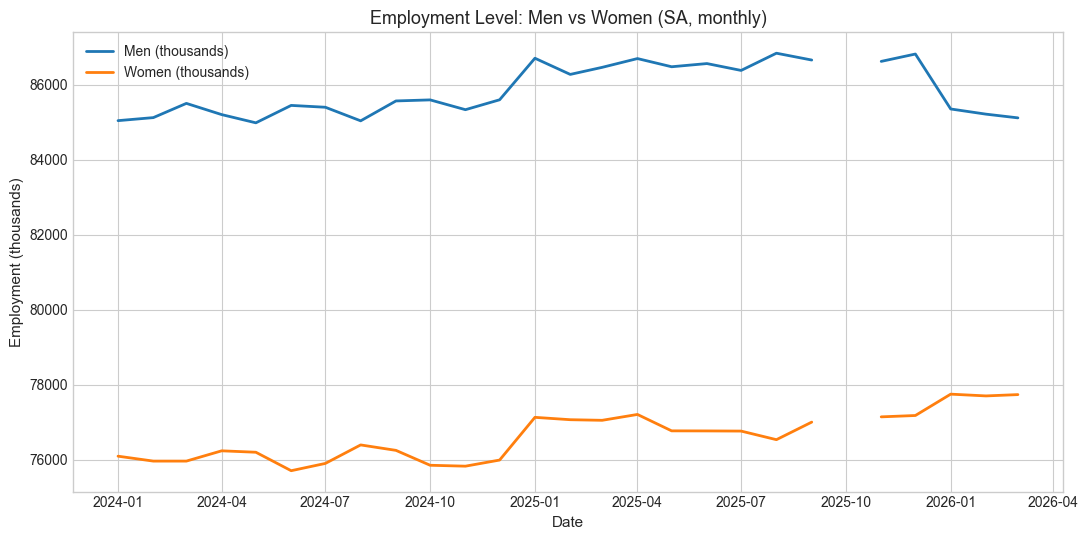

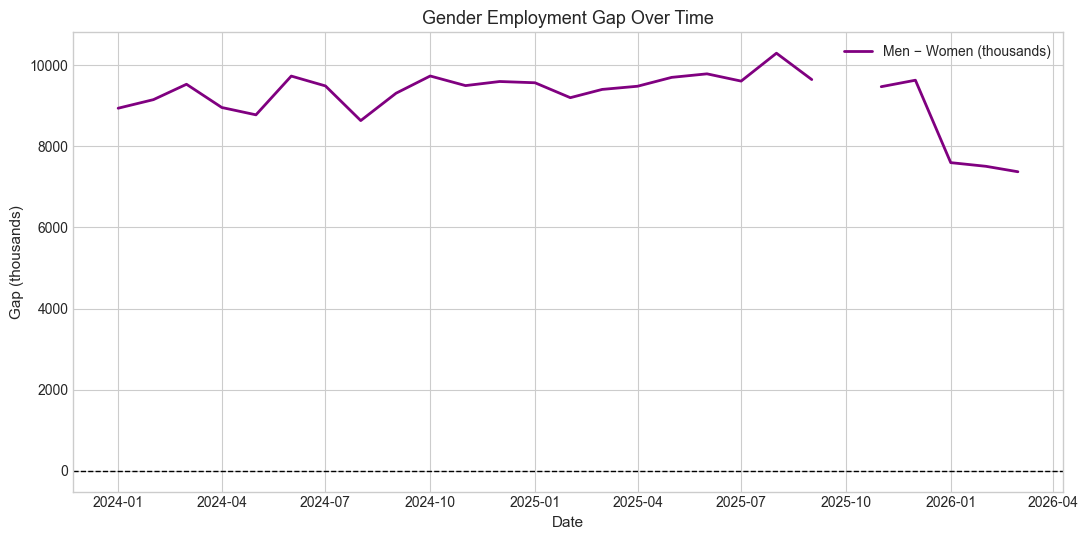

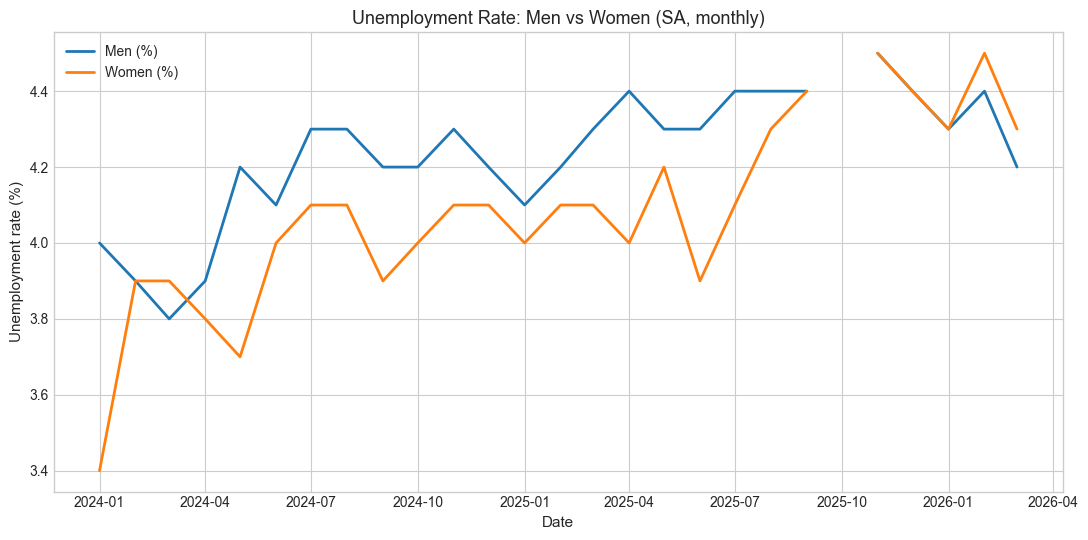

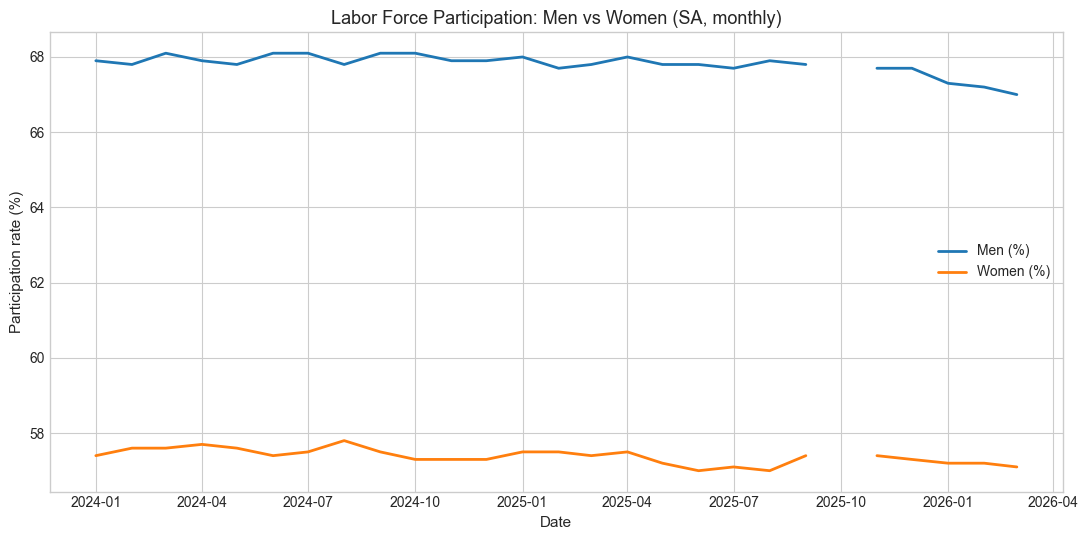

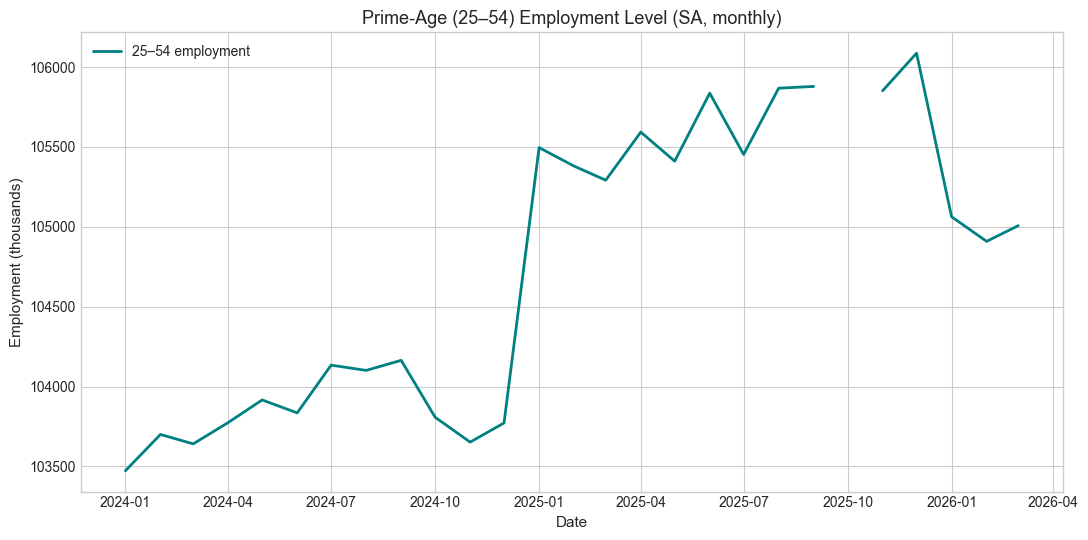

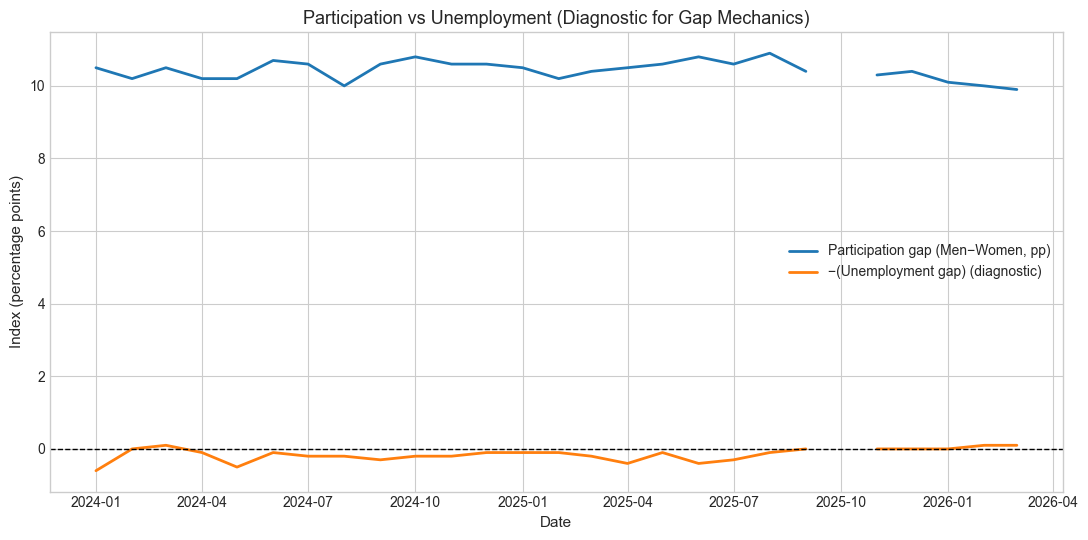

In [5]:
def save_fig(fig, name: str) -> None:
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / name, dpi=160, bbox_inches="tight")
    plt.show()


# 1) Men vs women employment
fig, ax = plt.subplots()
ax.plot(feat["Date"], feat["Men_Employment"], label="Men (thousands)", lw=2)
ax.plot(feat["Date"], feat["Women_Employment"], label="Women (thousands)", lw=2)
ax.set_title("Employment Level: Men vs Women (SA, monthly)")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend()
save_fig(fig, "01_men_vs_women_employment.png")

# 2) Employment gap
fig, ax = plt.subplots()
ax.plot(feat["Date"], feat["Employment_Gap"], color="purple", lw=2, label="Men − Women (thousands)")
ax.axhline(0, color="k", ls="--", lw=1)
ax.set_title("Gender Employment Gap Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Gap (thousands)")
ax.legend()
save_fig(fig, "02_employment_gap_over_time.png")

# 3) Unemployment
fig, ax = plt.subplots()
ax.plot(feat["Date"], feat["Men_Unemployment"], label="Men (%)", lw=2)
ax.plot(feat["Date"], feat["Women_Unemployment"], label="Women (%)", lw=2)
ax.set_title("Unemployment Rate: Men vs Women (SA, monthly)")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment rate (%)")
ax.legend()
save_fig(fig, "03_unemployment_comparison.png")

# 4) Participation
fig, ax = plt.subplots()
ax.plot(feat["Date"], feat["Men_Participation"], label="Men (%)", lw=2)
ax.plot(feat["Date"], feat["Women_Participation"], label="Women (%)", lw=2)
ax.set_title("Labor Force Participation: Men vs Women (SA, monthly)")
ax.set_xlabel("Date")
ax.set_ylabel("Participation rate (%)")
ax.legend()
save_fig(fig, "04_participation_comparison.png")

# 5) Prime-age employment
fig, ax = plt.subplots()
ax.plot(feat["Date"], feat["Prime_Age_Employment"], color="teal", lw=2, label="25–54 employment")
ax.set_title("Prime-Age (25–54) Employment Level (SA, monthly)")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend()
save_fig(fig, "05_prime_age_employment_trend.png")

# 6) Drivers (diagnostic)
fig, ax = plt.subplots()
ax.plot(feat["Date"], feat["Participation_Driver_Index"], lw=2, label="Participation gap (Men−Women, pp)")
ax.plot(feat["Date"], feat["Unemployment_Driver_Index"], lw=2, label="−(Unemployment gap) (diagnostic)")
ax.axhline(0, color="k", ls="--", lw=1)
ax.set_title("Participation vs Unemployment (Diagnostic for Gap Mechanics)")
ax.set_xlabel("Date")
ax.set_ylabel("Index (percentage points)")
ax.legend()
save_fig(fig, "06_gap_driver_participation_vs_unemployment.png")


## 5) Insights (interpretation)

Summarize start→end changes and averages. Connect back to business questions; note sample window limits.


In [6]:
first = feat.iloc[0]
last = feat.iloc[-1]

lines = []
lines.append(
    f"Sample window: {first['Date'].date()} to {last['Date'].date()} (monthly SA series)."
)
lines.append(
    f"Employment gap (Men−Women): {first['Employment_Gap']:.0f} → {last['Employment_Gap']:.0f} "
    f"(change {last['Employment_Gap'] - first['Employment_Gap']:.0f} thousand)."
)
lines.append(
    f"Men employment change: {last['Men_Employment'] - first['Men_Employment']:.0f} thousand; "
    f"Women: {last['Women_Employment'] - first['Women_Employment']:.0f} thousand."
)
lines.append(
    f"Mean participation gap (Men−Women): {feat['Participation_Gap'].mean():.2f} pp; "
    f"mean unemployment gap (Men−Women): {feat['Unemployment_Gap'].mean():.2f} pp."
)
lines.append(
    f"Mean unemployment: Men {feat['Men_Unemployment'].mean():.2f}%, "
    f"Women {feat['Women_Unemployment'].mean():.2f}%."
)
lines.append(
    f"Prime-age employment change: {last['Prime_Age_Employment'] - first['Prime_Age_Employment']:.0f} thousand."
)

print("\n".join(lines))

insight_text = "U.S. Labor Market Demography — Key Insights\n" + "=" * 50 + "\n\n" + "\n".join(lines) + "\n"


Sample window: 2024-01-01 to 2026-03-01 (monthly SA series).
Employment gap (Men−Women): 8941 → 7374 (change -1567 thousand).
Men employment change: 74 thousand; Women: 1641 thousand.
Mean participation gap (Men−Women): 10.43 pp; mean unemployment gap (Men−Women): 0.15 pp.
Mean unemployment: Men 4.23%, Women 4.08%.
Prime-age employment change: 1534 thousand.


In [7]:
# Save artifacts
feat.to_csv(OUTPUT_DIR / "cleaned_data.csv", index=False)
(OUTPUT_DIR / "insights_summary.txt").write_text(insight_text, encoding="utf-8")

print("Wrote:", (OUTPUT_DIR / "cleaned_data.csv").resolve())
print("Wrote:", (OUTPUT_DIR / "insights_summary.txt").resolve())


Wrote: C:\Github\demography-hiring-analysis\outputs\cleaned_data.csv
Wrote: C:\Github\demography-hiring-analysis\outputs\insights_summary.txt


## 6) Findings

This section summarizes what the analysis shows, **why it matters** for labor-market and equity questions, and how it maps to the business questions in the introduction.

### Summary of key insights

**Gender employment trends**  
Over the sample window (monthly, seasonally adjusted data from early 2024 through early 2026), **women’s employment rose much more than men’s** in level terms, while **men’s employment remained comparatively flat**. Because employment is measured in **thousands of workers**, the **gender employment gap (men minus women)** **narrowed** over the period. That pattern suggests the improvement in parity is driven primarily by **growth on the women’s side**, not by a large decline in men’s employment—directly addressing whether the gap is closing because women are improving, men are declining, or both.

**Unemployment differences**  
**Men’s unemployment rate is slightly higher on average** than women’s in this sample, and the **gender gap in unemployment rates is small** relative to the gap in participation (see below). That matters for question (3): men and women do not experience identical unemployment, but **joblessness differentials are modest** here compared with **who is in the labor force at all**.

**Labor force participation patterns**  
**Men’s participation exceeds women’s by roughly ten percentage points on average**, and that **participation gap is large and persistent** compared with the unemployment-rate gap. For question (2), this supports the view that **who participates** (attachment to the labor force) explains **much more of the employment-level difference** between men and women than **who is unemployed among participants**—at least in this window and with these official definitions.

**Prime-age (25–54) workforce trends**  
**Prime-age employment increases** over the period alongside the gender employment story. That connects to question (4): **core working-age employment** does not contradict a narrative of **broad labor demand**; the gender employment story unfolds **within** that macro backdrop rather than in isolation.

### Additional interpretive insights

1. **Gap dynamics vs. levels**  
   The **employment gap** can shrink even when **both** genders’ employment rise, if women’s series rises faster. Treating “smaller gap” only as “men lost jobs” would be misleading; here the evidence points to **asymmetric growth**.

2. **Structural vs. cyclical framing**  
   **Participation gaps** tend to move slowly and reflect long-run constraints and choices (caregiving, industry mix, norms, policy). **Unemployment rates** are more cyclical. Seeing a **stable wide participation gap** with a **narrow unemployment gap** is consistent with interpreting the **employment gap** as **structurally participation-heavy** in this sample, not mainly a story of divergent job loss.

3. **Diagnostic chart (participation vs. unemployment)**  
   The “driver” view in the notebook is **exploratory**: it helps **compare magnitudes** (participation gap vs. unemployment gap) for storytelling. It is **not** a causal decomposition. In an interview, you would say you use it to **hypothesize** where to dig deeper (e.g., participation-focused policies vs. recession unemployment spikes).

---

### Data Availability Gap

**What the issue is**  
All BLS exports used in this project share a **synchronized missing value for October 2025** (the source encodes unavailable points as `-`, which we coerce to missing). After merging, **that month has no valid values** for employment, unemployment, participation, or prime-age employment. On the line charts, this shows up as a **break in the series** between September and November 2025. **November and December 2025 and January 2026 are present** in the data; the problem is the **single missing month**, not a multi-month blackout—but it still affects how you read **momentum and month-over-month changes** around **late 2025 and early 2026**.

**Possible causes**  
Typical explanations include **official release timing or revision cycles** (a value not yet published or withheld in the extract), **extraction timing** (download taken before October was finalized), or **incomplete series rows** in the export. The **alignment across every series** points to a **common source-month issue**, not a merge bug.

**How it affects interpretation**  
You **cannot** treat October 2025 as zero or as equal to adjacent months without biasing trends. **Month-over-month growth** that would cross October is **not trustworthy** for that step. Comparisons that **span the missing month** (for example, narratives about “fall 2025 into early 2026”) should **explicitly note the hole** so stakeholders do not over-read a **visual dip or connector** as a real economic move.

**Actions taken**  
We **did not impute** October 2025. Missing values remain **explicit** in the merged table and plots. Analysis and narrative emphasize **valid months** and **start-to-end** summaries where appropriate, and call out the limitation in documentation so the project stays **auditable and honest**.
